In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from textblob import TextBlob

In [2]:
from textblob import TextBlob

print(TextBlob("I love AI").sentiment)

Sentiment(polarity=0.5, subjectivity=0.6)


In [5]:
df = pd.read_csv("../data/raw/AAPL.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [6]:
df.columns


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/AAPL.csv")

df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


In [3]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB


In [4]:
df["Price_Change"] = df["Close"] - df["Open"]

df[["Date", "Open", "Close", "Price_Change"]].head()

,Date,Open,Close,Price_Change
0,2009-01-02,2.575630,2.721686,0.146056
1,2009-01-05,2.794266,2.836553,0.042287
2,2009-01-06,2.877641,2.789767,-0.087874
3,2009-01-07,2.753477,2.729484,-0.023993
4,2009-01-08,2.712090,2.780169,0.068079


In [5]:
df["Sentiment"] = df["Price_Change"].apply(lambda x: 1 if x > 0 else 0)

df[["Price_Change", "Sentiment"]].head()

,Price_Change,Sentiment
0,0.146056,1
1,0.042287,1
2,-0.087874,0
3,-0.023993,0
4,0.068079,1


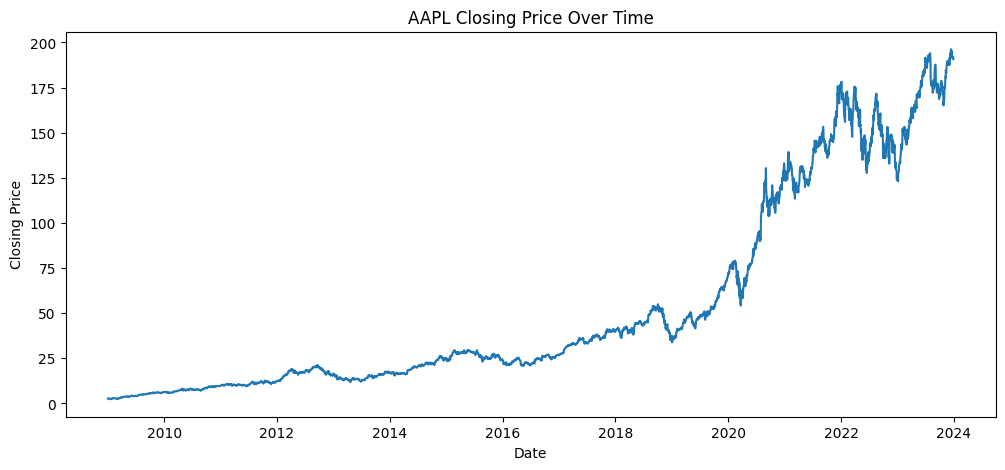

In [6]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Close"])

plt.title("AAPL Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

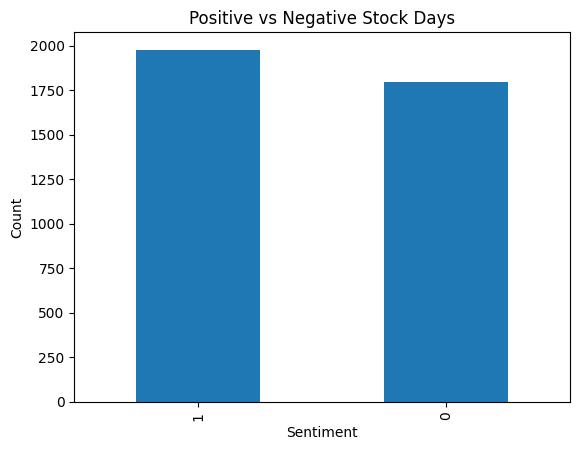

In [7]:
df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Positive vs Negative Stock Days")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

correlation = df.corr(numeric_only=True)

correlation

# Conclusion

In this task, we analyzed Apple stock price data using Python.

We performed:
- Data loading
- Data inspection
- Date conversion
- Feature engineering
- Sentiment labeling
- Data visualization
- Correlation analysis

The analysis showed strong relationships between stock price features such as Open, Close, High, and Low prices.

We also created a simple sentiment classification based on stock price movement.